In [11]:
# 1. Setup — only libraries that already ship with Colab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 40)
print("Environment ready ✅")

Environment ready ✅


In [12]:
# 2. Sample backlog — edit freely
backlog = pd.DataFrame([
    {"initiative": "One-click checkout",          "business_value": 8, "time_criticality": 7, "risk_reduction": 4, "job_size": 3,
     "cost_usd": 40_000,  "benefit_usd": 260_000},
    {"initiative": "Mobile push notifications",    "business_value": 6, "time_criticality": 5, "risk_reduction": 3, "job_size": 2,
     "cost_usd": 25_000,  "benefit_usd": 90_000},
    {"initiative": "Multi-currency pricing",       "business_value": 7, "time_criticality": 8, "risk_reduction": 6, "job_size": 8,
     "cost_usd": 120_000, "benefit_usd": 300_000},
    {"initiative": "Referral program",             "business_value": 9, "time_criticality": 4, "risk_reduction": 5, "job_size": 5,
     "cost_usd": 60_000,  "benefit_usd": 340_000},
    {"initiative": "Legacy API migration",         "business_value": 3, "time_criticality": 9, "risk_reduction": 8, "job_size": 13,
     "cost_usd": 200_000, "benefit_usd": 150_000},
    {"initiative": "In-app support chat",          "business_value": 6, "time_criticality": 3, "risk_reduction": 2, "job_size": 5,
     "cost_usd": 55_000,  "benefit_usd": 110_000},
    {"initiative": "Personalized recommendations", "business_value": 8, "time_criticality": 5, "risk_reduction": 5, "job_size": 8,
     "cost_usd": 100_000, "benefit_usd": 280_000},
    {"initiative": "GDPR consent overhaul",        "business_value": 2, "time_criticality": 10,"risk_reduction": 9, "job_size": 5,
     "cost_usd": 70_000,  "benefit_usd": 80_000},
    {"initiative": "Dark mode",                    "business_value": 4, "time_criticality": 2, "risk_reduction": 1, "job_size": 2,
     "cost_usd": 15_000,  "benefit_usd": 40_000},
    {"initiative": "A/B testing platform",         "business_value": 5, "time_criticality": 4, "risk_reduction": 7, "job_size": 8,
     "cost_usd": 90_000,  "benefit_usd": 130_000},
])
backlog

,initiative,business_value,time_criticality,risk_reduction,job_size,cost_usd,benefit_usd
0,One-click checkout,8,7,4,3,40000,260000
1,Mobile push notifications,6,5,3,2,25000,90000
2,Multi-currency pricing,7,8,6,8,120000,300000
3,Referral program,9,4,5,5,60000,340000
4,Legacy API migration,3,9,8,13,200000,150000
5,In-app support chat,6,3,2,5,55000,110000
6,Personalized recommendations,8,5,5,8,100000,280000
7,GDPR consent overhaul,2,10,9,5,70000,80000
8,Dark mode,4,2,1,2,15000,40000
9,A/B testing platform,5,4,7,8,90000,130000


In [13]:
# 3. Compute WSJF
backlog["cost_of_delay"] = (
    backlog["business_value"] + backlog["time_criticality"] + backlog["risk_reduction"]
)
backlog["wsjf"] = (backlog["cost_of_delay"] / backlog["job_size"]).round(2)

# 4. Compute a simple ROI (%) for comparison
backlog["roi_pct"] = (
    (backlog["benefit_usd"] - backlog["cost_usd"]) / backlog["cost_usd"] * 100
).round(0)

ranked_wsjf = backlog.sort_values("wsjf", ascending=False).reset_index(drop=True)
ranked_wsjf.index += 1
ranked_wsjf[["initiative", "cost_of_delay", "job_size", "wsjf", "roi_pct"]]

,initiative,cost_of_delay,job_size,wsjf,roi_pct
1,Mobile push notifications,14,2,7.00,260.0
2,One-click checkout,19,3,6.33,550.0
3,GDPR consent overhaul,21,5,4.20,14.0
4,Referral program,18,5,3.60,467.0
5,Dark mode,7,2,3.50,167.0
6,Multi-currency pricing,21,8,2.62,150.0
7,Personalized recommendations,18,8,2.25,180.0
8,In-app support chat,11,5,2.20,100.0
9,A/B testing platform,16,8,2.00,44.0
10,Legacy API migration,20,13,1.54,-25.0


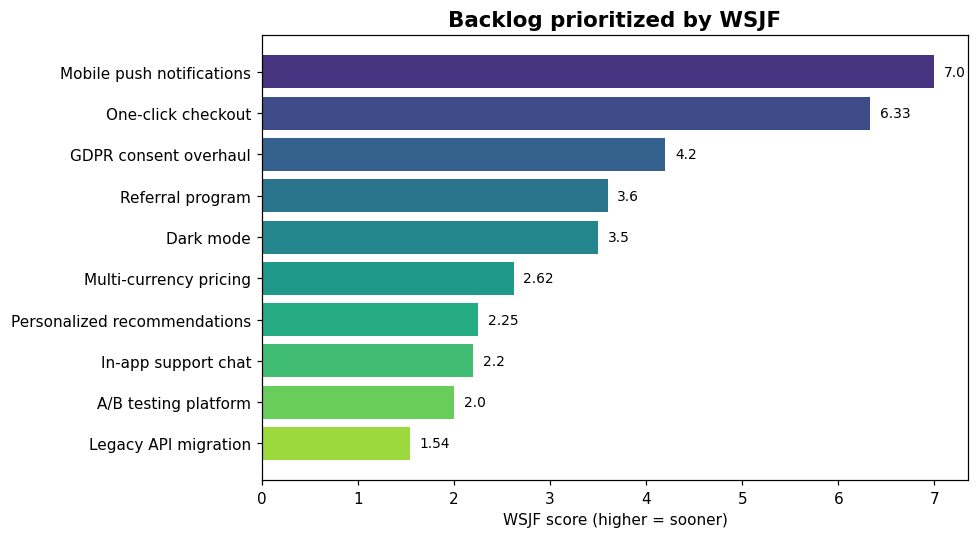

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(ranked_wsjf)))
bars = ax.barh(ranked_wsjf["initiative"], ranked_wsjf["wsjf"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("WSJF score (higher = sooner)")
ax.set_title("Backlog prioritized by WSJF", fontsize=14, fontweight="bold")
for bar, val in zip(bars, ranked_wsjf["wsjf"]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f"{val}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
compare = backlog.copy()
compare["wsjf_rank"] = compare["wsjf"].rank(ascending=False).astype(int)
compare["roi_rank"] = compare["roi_pct"].rank(ascending=False).astype(int)
compare["rank_delta"] = compare["roi_rank"] - compare["wsjf_rank"]
compare = compare.sort_values("wsjf_rank")

display(compare[["initiative", "wsjf_rank", "roi_rank", "rank_delta"]]
        .set_index("initiative"))

biggest_mover = compare.loc[compare["rank_delta"].abs().idxmax()]
print(f"\nBiggest disagreement: '{biggest_mover['initiative']}' "
      f"(WSJF rank {int(biggest_mover['wsjf_rank'])} vs ROI rank {int(biggest_mover['roi_rank'])}) — "
      f"WSJF's time-criticality / risk-reduction terms are pulling this one forward "
      f"even though its dollar ROI alone wouldn't justify the priority.")

,wsjf_rank,roi_rank,rank_delta
initiative,,,
Mobile push notifications,1,3,2
One-click checkout,2,1,-1
GDPR consent overhaul,3,9,6
Referral program,4,2,-2
Dark mode,5,5,0
Multi-currency pricing,6,6,0
Personalized recommendations,7,4,-3
In-app support chat,8,7,-1
A/B testing platform,9,8,-1



Biggest disagreement: 'GDPR consent overhaul' (WSJF rank 3 vs ROI rank 9) — WSJF's time-criticality / risk-reduction terms are pulling this one forward even though its dollar ROI alone wouldn't justify the priority.


### 5. Visualizing the Rank Disagreement
This chart highlights the shift in priority. A positive 'Rank Delta' means the initiative moves **up** the priority list when using WSJF compared to using ROI.

In [16]:
import ipywidgets as widgets
from IPython.display import display, clear_output

item_dropdown = widgets.Dropdown(
    options=list(backlog["initiative"]), description="Initiative:",
    style={"description_width": "initial"}, layout=widgets.Layout(width="350px"))
bv_slider = widgets.IntSlider(value=5, min=1, max=10, description="Business value")
tc_slider = widgets.IntSlider(value=5, min=1, max=10, description="Time criticality")
rr_slider = widgets.IntSlider(value=5, min=1, max=10, description="Risk reduction")
js_slider = widgets.IntSlider(value=5, min=1, max=13, description="Job size")
out = widgets.Output()

def sync_sliders(change=None):
    row = backlog[backlog["initiative"] == item_dropdown.value].iloc[0]
    bv_slider.value, tc_slider.value = int(row.business_value), int(row.time_criticality)
    rr_slider.value, js_slider.value = int(row.risk_reduction), int(row.job_size)

def redraw(change=None):
    temp = backlog.copy()
    mask = temp["initiative"] == item_dropdown.value
    temp.loc[mask, "business_value"] = bv_slider.value
    temp.loc[mask, "time_criticality"] = tc_slider.value
    temp.loc[mask, "risk_reduction"] = rr_slider.value
    temp.loc[mask, "job_size"] = js_slider.value
    temp["wsjf"] = ((temp.business_value + temp.time_criticality + temp.risk_reduction)
                     / temp.job_size).round(2)
    temp = temp.sort_values("wsjf", ascending=False).reset_index(drop=True)
    temp.index += 1
    with out:
        clear_output(wait=True)
        display(temp[["initiative", "wsjf"]].style.apply(
            lambda s: ['background-color: #cadcfc' if v == item_dropdown.value else ''
                       for v in temp["initiative"]], axis=0, subset=["initiative"]))

item_dropdown.observe(lambda c: (sync_sliders(), redraw()), names="value")
for s in (bv_slider, tc_slider, rr_slider, js_slider):
    s.observe(redraw, names="value")

sync_sliders(); redraw()
display(widgets.VBox([item_dropdown, bv_slider, tc_slider, rr_slider, js_slider, out]))

In [17]:
compare = backlog.copy()
compare["wsjf_rank"] = compare["wsjf"].rank(ascending=False).astype(int)
compare["roi_rank"] = compare["roi_pct"].rank(ascending=False).astype(int)
compare["rank_delta"] = compare["roi_rank"] - compare["wsjf_rank"]
compare = compare.sort_values("wsjf_rank")

display(compare[["initiative", "wsjf", "wsjf_rank", "roi_pct", "roi_rank", "rank_delta"]]
        .set_index("initiative"))

biggest_mover = compare.loc[compare["rank_delta"].abs().idxmax()]
print(f"\nBiggest disagreement: '{biggest_mover['initiative']}' "
      f"(WSJF rank {int(biggest_mover['wsjf_rank'])} vs ROI rank {int(biggest_mover['roi_rank'])}) — "
      f"WSJF's time-criticality / risk-reduction terms are pulling this one forward "
      f"even though its dollar ROI alone wouldn't justify the priority.")

,wsjf,wsjf_rank,roi_pct,roi_rank,rank_delta
initiative,,,,,
Mobile push notifications,7.00,1,260.0,3,2
One-click checkout,6.33,2,550.0,1,-1
GDPR consent overhaul,4.20,3,14.0,9,6
Referral program,3.60,4,467.0,2,-2
Dark mode,3.50,5,167.0,5,0
Multi-currency pricing,2.62,6,150.0,6,0
Personalized recommendations,2.25,7,180.0,4,-3
In-app support chat,2.20,8,100.0,7,-1
A/B testing platform,2.00,9,44.0,8,-1



Biggest disagreement: 'GDPR consent overhaul' (WSJF rank 3 vs ROI rank 9) — WSJF's time-criticality / risk-reduction terms are pulling this one forward even though its dollar ROI alone wouldn't justify the priority.


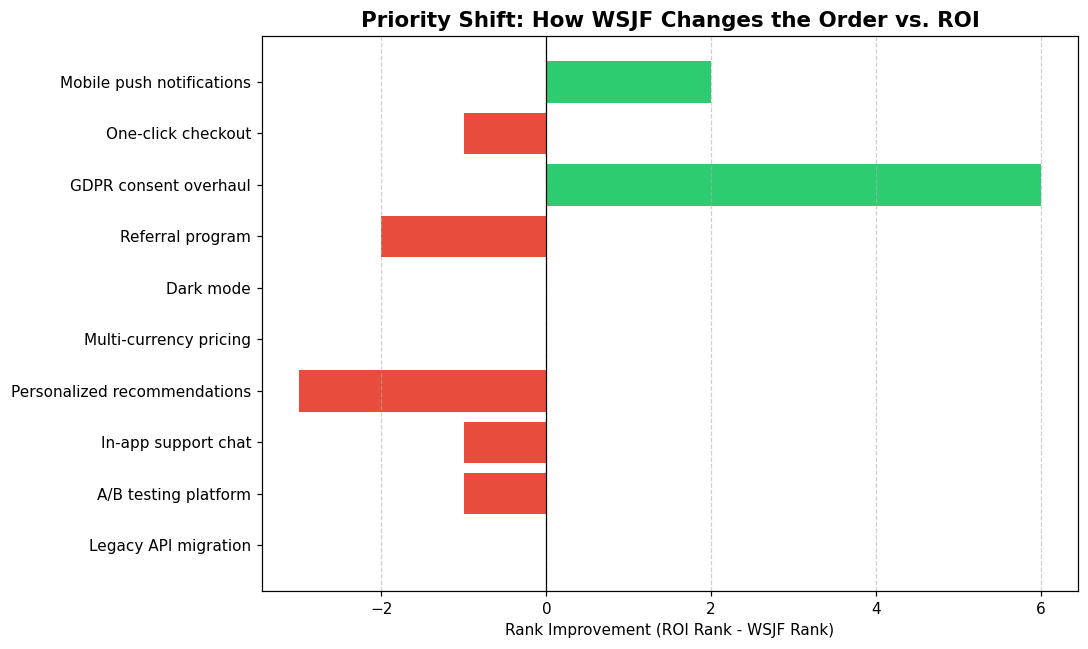

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

# Sort by WSJF rank for consistent display
plot_data = compare.sort_values("wsjf_rank", ascending=True)

# Color mapping: Green for WSJF favoring, Red for ROI favoring
colors = ['#2ecc71' if x > 0 else '#e74c3c' if x < 0 else '#95a5a6' for x in plot_data['rank_delta']]

bars = ax.barh(plot_data["initiative"], plot_data["rank_delta"], color=colors)
ax.invert_yaxis()

ax.set_xlabel("Rank Improvement (ROI Rank - WSJF Rank)")
ax.set_title("Priority Shift: How WSJF Changes the Order vs. ROI", fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.6)

# Add center line
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()